In [7]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats

In [8]:
clades = ['h3nx', 'na_avian', 'eurasian_avian', 'swine', 'human', 'equine', 'canine']

In [9]:
# for clade in clades:
    
#     with open(f"{clade}/summary.nwk", 'r') as file:
#         tree = file.read()

#     # removing commas between segments
#     modified = re.sub(r'rea=([^]\)]+)', lambda match: f'rea="{match.group(1).replace(",", "-")}"', tree)

#     # removing quotation marks around node names
#     modified = re.sub(r"'(TS_NODE_\d+)'", r'\1', modified)
#     modified = re.sub(r"'(NODE_\d+)'", r'\1', modified)

#     with open(f"{clade}/summary_baltic.nwk", "w") as output:
#         output.write(modified.strip())


In [10]:
host_trees = {}

for clade in clades:
    
    path = f'{clade}/summary_baltic.nwk'
    mytree= bt.loadNewick(path, absoluteTime= False)

    
    host_trees[clade] = mytree

for clade in clades:
    
    mytree = host_trees[clade]

    for k in mytree.Objects:
        
        name = k.name if k.is_leaf() else k.traits["label"]


In [11]:
def parse_dates(aln_path: str):
    records = SeqIO.parse(aln_path, 'fasta')
    dates = {}
    for record in records:
        name = record.name
        # date_str = name.split('|')[-1]
        date = None
        for token in name.split('|'):
            if re.fullmatch(r'[\d\-/]{4,}', token) and not re.fullmatch(r'\d{5,}', token):
                if token.count('/') == 2:
                    date = datetime.strptime(token, '%m/%d/%Y')
                elif token.count('/') == 1:
                    date = datetime.strptime(token, '%m/%Y')
                elif token.count('-') == 2:
                    date = datetime.strptime(token, '%Y-%m-%d')
                elif token.count('-') == 1:
                    date = datetime.strptime(token, '%Y-%m')
                else:
                    date = datetime.strptime(token, '%Y')
        if not date:
            pass
        else:
            dec_date = date.year + ((date.month - 1) * 30 + date.day) / 365.0
            dates[name] = dec_date
    return dates

def estimate_clock_rate(tree_path: str, aln_path: str, outdir='.') -> (float, float):
    
    # This code was adapted from the  'estimate_clock_model' method in the treetime/wrappers.py.
    tree: Tree = Tree.get(path=tree_path, schema='newick', preserve_underscores=True)
    if len(tree.leaf_nodes()) > 1000:
        tree_path = os.path.join(outdir, os.path.split(tree_path)[-1] + '.sample1k.tre')
        taxa_labels = [t.label for t in tree.taxon_namespace]
        random.shuffle(taxa_labels)
        subtree: Tree = tree.extract_tree_with_taxa_labels(taxa_labels[:1000])
        subtree.write(path=tree_path, schema='newick')

    dates = parse_dates(aln_path)
    
    timetree = TreeTime(dates=dates, tree=tree_path, aln=aln_path, gtr='JC69', verbose=-1)  # TODO: JC->GTR?
          
    timetree.clock_filter(n_iqd=3, reroot='least-squares')
    timetree.use_covariation = True
    timetree.reroot()
    timetree.get_clock_model(covariation=True)
    
    # trying to get root here, but it changes quite unstably from inference to inference
    # should i resolve polytomies?
    timetree.run(root='least-squares', resolve_polytomies=True)

    inferred_root_date = timetree.tree.root.numdate
    print(f"inferred root date: {inferred_root_date:.4f}")

    r_val = timetree.clock_model['r_val']
    
    d2d = utils.DateConversion.from_regression(timetree.clock_model)
    clock_rate = round(d2d.clock_rate, 7)
    
    return d2d.clock_rate, r_val, inferred_root_date
    

In [12]:
host_stats = {}

for clade in clades:
    
    clock_rate, r_val, root_yr = estimate_clock_rate(f"{clade}/summary.nwk", f"{clade}/h3nx_ha.fasta")
    
    host_stats[clade] = {
    'clock_rate': clock_rate,
    'root_yr': root_yr
    }
    

inferred root date: 1933.2609
inferred root date: 1932.7665
inferred root date: 1926.3427
inferred root date: 1971.5112
inferred root date: 1967.2012
inferred root date: 1954.4713
inferred root date: 2004.4206


In [13]:
print(host_stats)

{'h3nx': {'clock_rate': 0.002138290264854449, 'root_yr': 1933.2608627050627}, 'na_avian': {'clock_rate': 0.001425656115919803, 'root_yr': 1932.7665204689042}, 'eurasian_avian': {'clock_rate': 0.0009745955787266983, 'root_yr': 1926.3426536862212}, 'swine': {'clock_rate': 0.004172270693878036, 'root_yr': 1971.5111974461533}, 'human': {'clock_rate': 0.003972473701672012, 'root_yr': 1967.2011787845054}, 'equine': {'clock_rate': 0.0018885038965474204, 'root_yr': 1954.4713306059896}, 'canine': {'clock_rate': 0.0022685781524228905, 'root_yr': 2004.4205891941256}}


# 10 years

In [14]:
current_year = 2025
fit_time = 10

node_rea_counts = {clade: {} for clade in host_trees.keys()}
leaf_rea_counts = {clade: {} for clade in host_trees.keys()}

node_counts = {clade: {} for clade in host_trees.keys()}
leaf_counts = {clade: {} for clade in host_trees.keys()}

rea_fits = {clade: {} for clade in host_trees.keys()}
clonal_fits = {clade: {} for clade in host_trees.keys()}
rea_unfits = {clade: {} for clade in host_trees.keys()}
clonal_unfits = {clade: {} for clade in host_trees.keys()}


for clade in clades:
    
    mytree = host_trees[clade] 

    node_count = node_rea_count = leaf_count = leaf_rea_count= 0

    rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])


    for k in mytree.Objects:

        # for the fisher's exact test

        if k.is_leaf():

            leaf_count += 1

            if k.traits.get('is_reassorted'):

                leaf_rea_count += 1

        elif k.is_node():

            node_count += 1

            if k.traits.get('is_reassorted'):

                node_rea_count += 1

            # excluding nodes that are less than 10 years old 

            if (k.height / host_stats[clade]['clock_rate']) >= (current_year - host_stats[clade]['root_yr']) - fit_time:
                continue

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

            date = (leaf_height - k.height) / host_stats[clade]['clock_rate']

            if date > fit_time:

                if k.traits.get('is_reassorted'):
                    rea_fit += 1

                else:
                    clonal_fit += 1     

            else:

                if k.traits.get('is_reassorted'):
                    rea_unfit += 1

                else:
                    clonal_unfit += 1
                    
        node_counts[clade] = node_count
        leaf_counts[clade] = leaf_count

        node_rea_counts[clade] = node_rea_count
        leaf_rea_counts[clade] = leaf_rea_count


        rea_fits[clade] = rea_fit
        clonal_fits[clade] = clonal_fit

        rea_unfits[clade] = rea_unfit
        clonal_unfits[clade] = clonal_unfit


In [15]:
print(rea_fits)
print(clonal_fits)

print(rea_unfits)
print(clonal_unfits)

{'h3nx': 31, 'na_avian': 32, 'eurasian_avian': 17, 'swine': 19, 'human': 1, 'equine': 0, 'canine': 0}
{'h3nx': 274, 'na_avian': 140, 'eurasian_avian': 143, 'swine': 155, 'human': 64, 'equine': 61, 'canine': 15}
{'h3nx': 225, 'na_avian': 153, 'eurasian_avian': 40, 'swine': 34, 'human': 3, 'equine': 1, 'canine': 2}
{'h3nx': 712, 'na_avian': 434, 'eurasian_avian': 281, 'swine': 447, 'human': 130, 'equine': 105, 'canine': 116}


In [16]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []


for clade in clades:
    a = rea_fits[clade]
    b = rea_unfits[clade]
    c = clonal_fits[clade]
    d = clonal_unfits[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts for {clade} are 0")
        ci_low, ci_high = float('nan'), float('nan')
        
    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade}: p-value = {p_value:.8f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

h3nx: p-value = 0.00000006, odds ratio = 0.36, 95% CI = (0.23986513799466425, 0.5343798588277326)
na_avian: p-value = 0.05465512, odds ratio = 0.65, 95% CI = (0.4234713074174412, 0.9926965051550775)
eurasian_avian: p-value = 0.65387252, odds ratio = 0.84, 95% CI = (0.4573625091235739, 1.5249579317966795)
swine: p-value = 0.14293841, odds ratio = 1.61, 95% CI = (0.8929946153525022, 2.908386885064179)
human: p-value = 1.00000000, odds ratio = 0.68, 95% CI = (0.06905322335937411, 6.638963656944821)
one of your counts for equine are 0
equine: p-value = 1.00000000, odds ratio = 0.00, 95% CI = (nan, nan)
one of your counts for canine are 0
canine: p-value = 1.00000000, odds ratio = 0.00, 95% CI = (nan, nan)


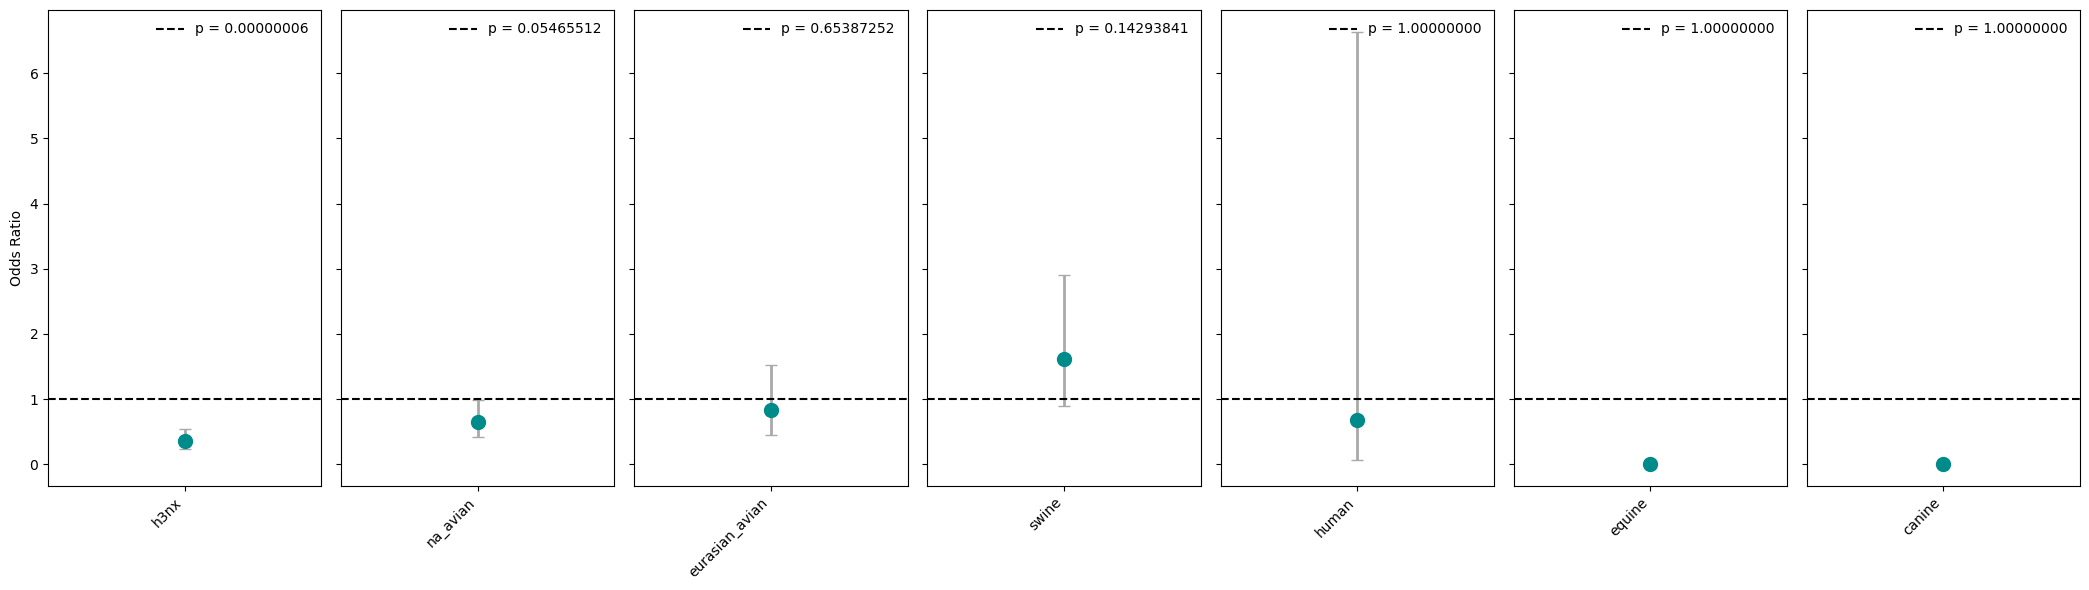

In [17]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    #  error bars
    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)

    ax.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()


# 6 years

In [18]:
current_year = 2025
fit_time = 6

node_rea_counts = {clade: {} for clade in host_trees.keys()}
leaf_rea_counts = {clade: {} for clade in host_trees.keys()}

node_counts = {clade: {} for clade in host_trees.keys()}
leaf_counts = {clade: {} for clade in host_trees.keys()}

rea_fits = {clade: {} for clade in host_trees.keys()}
clonal_fits = {clade: {} for clade in host_trees.keys()}
rea_unfits = {clade: {} for clade in host_trees.keys()}
clonal_unfits = {clade: {} for clade in host_trees.keys()}


for clade in clades:
    
    mytree = host_trees[clade] 

    node_count = node_rea_count = leaf_count = leaf_rea_count= 0

    rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])


    for k in mytree.Objects:

        # for the fisher's exact test

        if k.is_leaf():

            leaf_count += 1

            if k.traits.get('is_reassorted'):

                leaf_rea_count += 1

        elif k.is_node():

            node_count += 1

            if k.traits.get('is_reassorted'):

                node_rea_count += 1


            # excluding nodes that are less than 6 years old 

            if (k.height / host_stats[clade]['clock_rate']) >= (current_year - host_stats[clade]['root_yr']) - fit_time:
                continue


            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

            date = (leaf_height - k.height) / host_stats[clade]['clock_rate']


            if date > fit_time:

                if k.traits.get('is_reassorted'):
                    rea_fit += 1

                else:
                    clonal_fit += 1     

            else:

                if k.traits.get('is_reassorted'):
                    rea_unfit += 1

                else:
                    clonal_unfit += 1
                    
        node_counts[clade] = node_count
        leaf_counts[clade] = leaf_count

        node_rea_counts[clade] = node_rea_count
        leaf_rea_counts[clade] = leaf_rea_count


        rea_fits[clade] = rea_fit
        clonal_fits[clade] = clonal_fit

        rea_unfits[clade] = rea_unfit
        clonal_unfits[clade] = clonal_unfit


In [19]:
print(rea_fits)
print(clonal_fits)

print(rea_unfits)
print(clonal_unfits)

{'h3nx': 66, 'na_avian': 54, 'eurasian_avian': 25, 'swine': 35, 'human': 1, 'equine': 0, 'canine': 0}
{'h3nx': 455, 'na_avian': 208, 'eurasian_avian': 205, 'swine': 290, 'human': 73, 'equine': 85, 'canine': 48}
{'h3nx': 208, 'na_avian': 185, 'eurasian_avian': 34, 'swine': 71, 'human': 3, 'equine': 1, 'canine': 2}
{'h3nx': 711, 'na_avian': 524, 'eurasian_avian': 258, 'swine': 860, 'human': 150, 'equine': 92, 'canine': 251}


In [20]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []


for clade in clades:
    
    a = rea_fits[clade]
    b = rea_unfits[clade]
    c = clonal_fits[clade]
    d = clonal_unfits[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts for {clade} are 0")
        ci_low, ci_high = float('nan'), float('nan')
        
    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade}: p-value = {p_value:.6f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

h3nx: p-value = 0.000003, odds ratio = 0.50, 95% CI = (0.3670063326964819, 0.6698908583359229)
na_avian: p-value = 0.093028, odds ratio = 0.74, 95% CI = (0.5217836516821985, 1.0363095468480665)
eurasian_avian: p-value = 0.889405, odds ratio = 0.93, 95% CI = (0.5349859899325923, 1.6007055992117858)
swine: p-value = 0.082883, odds ratio = 1.46, 95% CI = (0.9546567074078265, 2.238582321321549)
human: p-value = 1.000000, odds ratio = 0.68, 95% CI = (0.07002743970218193, 6.6992477673042234)
one of your counts for equine are 0
equine: p-value = 1.000000, odds ratio = 0.00, 95% CI = (nan, nan)
one of your counts for canine are 0
canine: p-value = 1.000000, odds ratio = 0.00, 95% CI = (nan, nan)


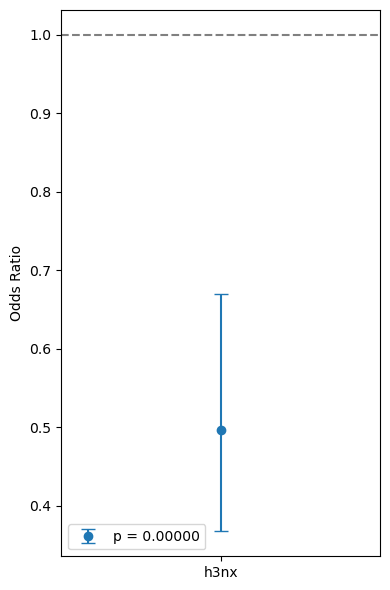

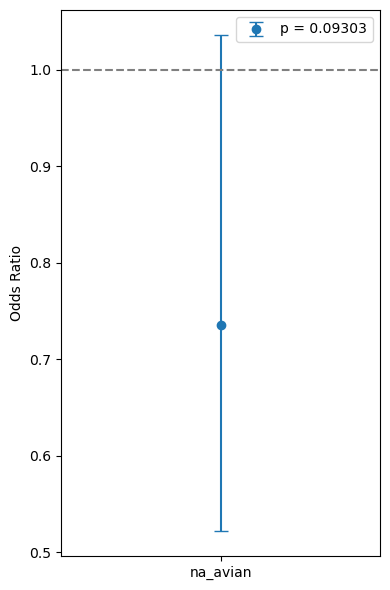

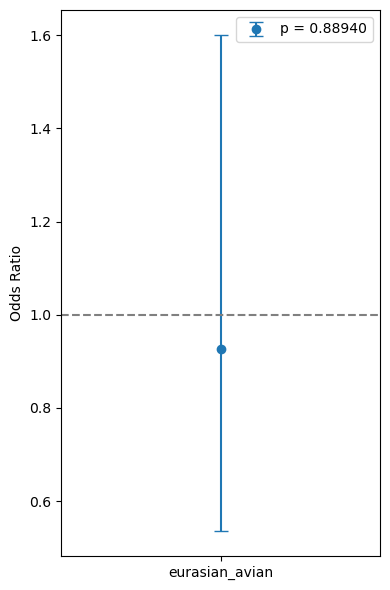

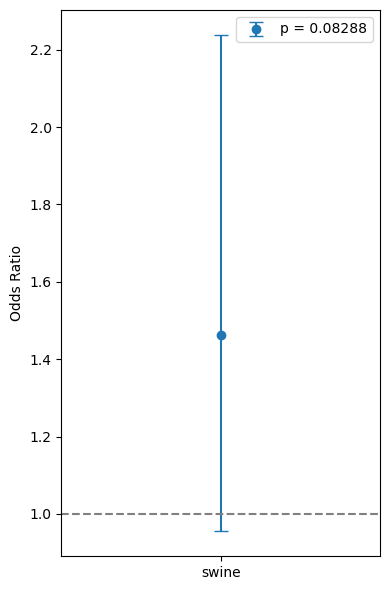

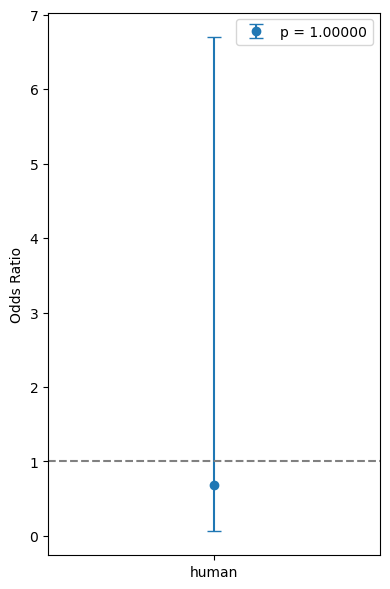

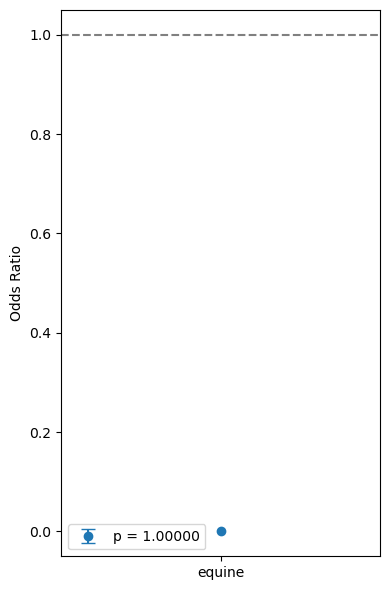

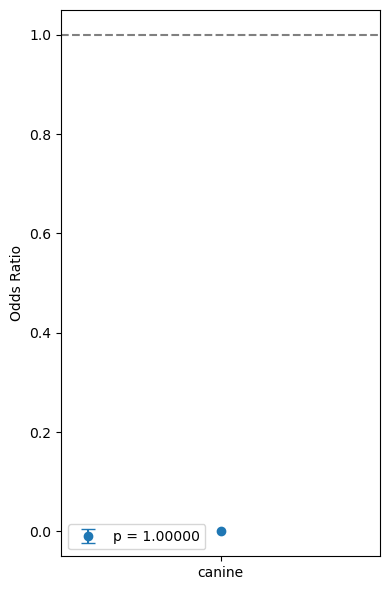

In [21]:
for clade, odds_ratio, p_value, (ci_low, ci_high) in zip(clades, odds_ratios, p_values, confidence):
    plt.figure(figsize=(4, 6))

    plt.errorbar(
        x=0,
        y=odds_ratio,
        yerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
        fmt='o',
        color='tab:blue',
        capsize=5,
        label=f'p = {p_value:.5f}'
    )

    plt.axhline(1, color='gray', linestyle='--')  # neutral OR
    plt.xticks([0], [clade])  # show label on x-axis
    plt.ylabel('Odds Ratio')
    plt.legend()
    plt.tight_layout()
    plt.show()

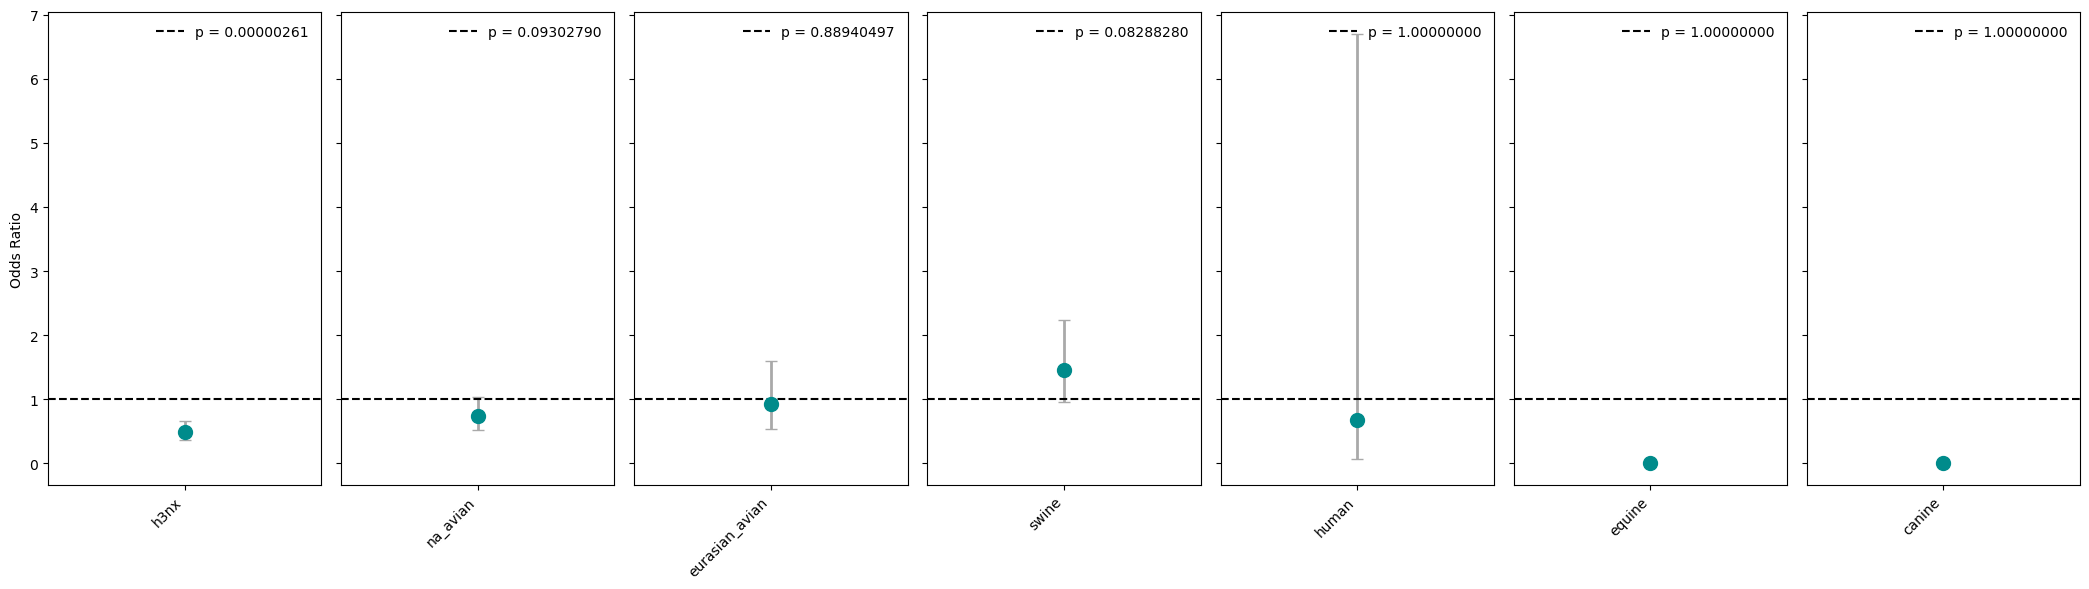

In [22]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    #  error bars
    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)

    ax.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()


# 2 years

In [23]:
current_year = 2025
fit_time = 2

node_rea_counts = {clade: {} for clade in host_trees.keys()}
leaf_rea_counts = {clade: {} for clade in host_trees.keys()}

node_counts = {clade: {} for clade in host_trees.keys()}
leaf_counts = {clade: {} for clade in host_trees.keys()}

rea_fits = {clade: {} for clade in host_trees.keys()}
clonal_fits = {clade: {} for clade in host_trees.keys()}
rea_unfits = {clade: {} for clade in host_trees.keys()}
clonal_unfits = {clade: {} for clade in host_trees.keys()}


for clade in clades:
    
    mytree = host_trees[clade] 

    node_count = node_rea_count = leaf_count = leaf_rea_count= 0

    rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])


    for k in mytree.Objects:

        # for the fisher's exact test

        if k.is_leaf():

            leaf_count += 1

            if k.traits.get('is_reassorted'):

                leaf_rea_count += 1

        elif k.is_node():

            node_count += 1

            if k.traits.get('is_reassorted'):

                node_rea_count += 1

            # for the lineage fitness analysis

            # excluding nodes that are less than 2 years old 

            if (k.height / host_stats[clade]['clock_rate']) >= (current_year - host_stats[clade]['root_yr']) - fit_time:
                continue

            # which is correct? 

            # 1. find the leaf with the highest root to tip divergence (height) 
            # then subtract the current node's height from that leafs height

            # leaf_height = max(leaf_heights[leaf][0] for leaf in k.leaves)

            # 2. find the tip with the latest date and subtract the current node's height from that leafs height

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

            date = (leaf_height - k.height) / host_stats[clade]['clock_rate']

            # date = int(max_date[:4]) - ((k.height / clock_rate) + root_yr)

            if date > fit_time:

                if k.traits.get('is_reassorted'):
                    rea_fit += 1

                else:
                    clonal_fit += 1     

            else:

                if k.traits.get('is_reassorted'):
                    rea_unfit += 1

                else:
                    clonal_unfit += 1
                    
        node_counts[clade] = node_count
        leaf_counts[clade] = leaf_count

        node_rea_counts[clade] = node_rea_count
        leaf_rea_counts[clade] = leaf_rea_count


        rea_fits[clade] = rea_fit
        clonal_fits[clade] = clonal_fit

        rea_unfits[clade] = rea_unfit
        clonal_unfits[clade] = clonal_unfit


In [24]:
print(rea_fits)
print(clonal_fits)

print(rea_unfits)
print(clonal_unfits)

{'h3nx': 152, 'na_avian': 118, 'eurasian_avian': 37, 'swine': 87, 'human': 2, 'equine': 1, 'canine': 0}
{'h3nx': 779, 'na_avian': 360, 'eurasian_avian': 297, 'swine': 655, 'human': 107, 'equine': 118, 'canine': 112}
{'h3nx': 148, 'na_avian': 165, 'eurasian_avian': 24, 'swine': 49, 'human': 2, 'equine': 1, 'canine': 3}
{'h3nx': 546, 'na_avian': 478, 'eurasian_avian': 189, 'swine': 993, 'human': 120, 'equine': 103, 'canine': 296}


In [25]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []


for clade in clades:
    a = rea_fits[clade]
    b = rea_unfits[clade]
    c = clonal_fits[clade]
    d = clonal_unfits[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts for {clade} are 0")
        ci_low, ci_high = float('nan'), float('nan')
        
    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade}: p-value = {p_value:.6f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

h3nx: p-value = 0.011651, odds ratio = 0.72, 95% CI = (0.5598336867417484, 0.9255823992715887)
na_avian: p-value = 0.728550, odds ratio = 0.95, 95% CI = (0.7226821291436105, 1.2476696259630338)
eurasian_avian: p-value = 1.000000, odds ratio = 0.98, 95% CI = (0.5687924624974374, 1.6921460395905652)
swine: p-value = 0.000000, odds ratio = 2.69, 95% CI = (1.8709873197476237, 3.8724997466970836)
human: p-value = 1.000000, odds ratio = 1.12, 95% CI = (0.15527046748242138, 8.100392747615178)
equine: p-value = 1.000000, odds ratio = 0.87, 95% CI = (0.05391286740659495, 14.132467779683322)
one of your counts for canine are 0
canine: p-value = 0.565612, odds ratio = 0.00, 95% CI = (nan, nan)


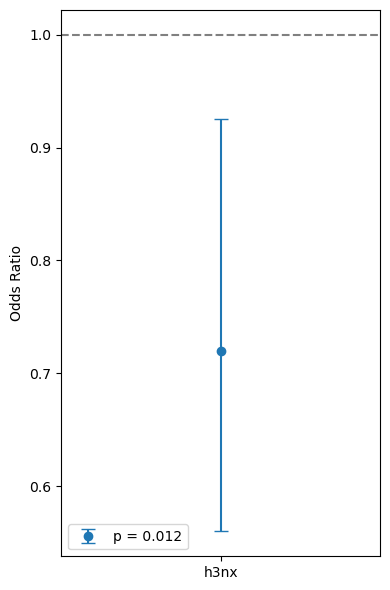

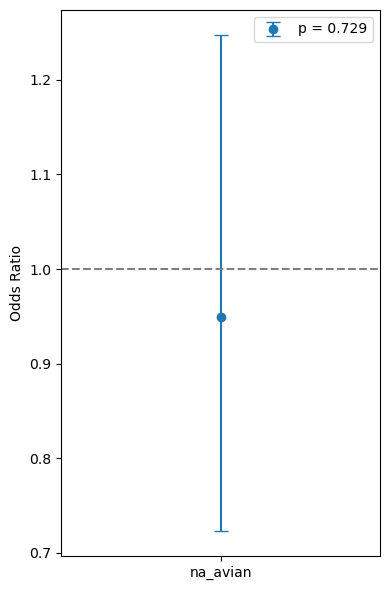

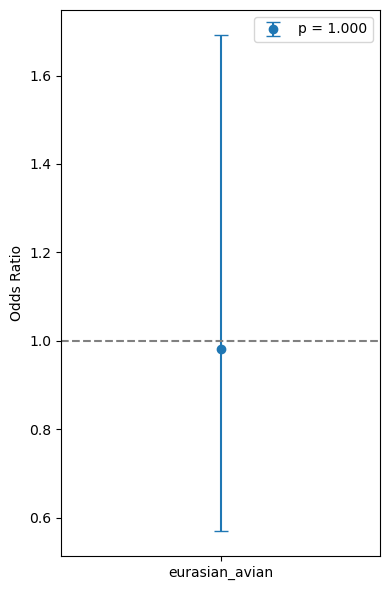

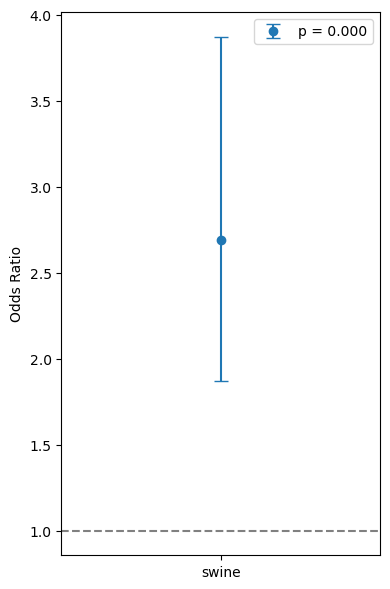

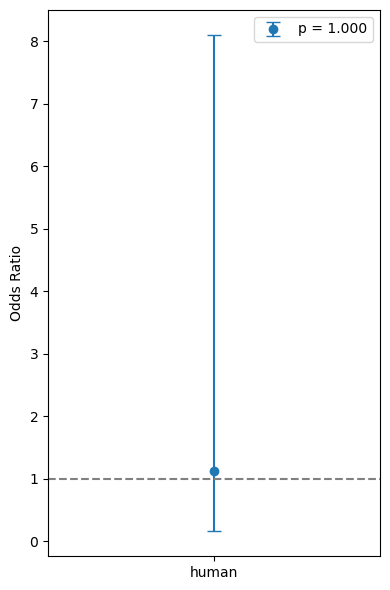

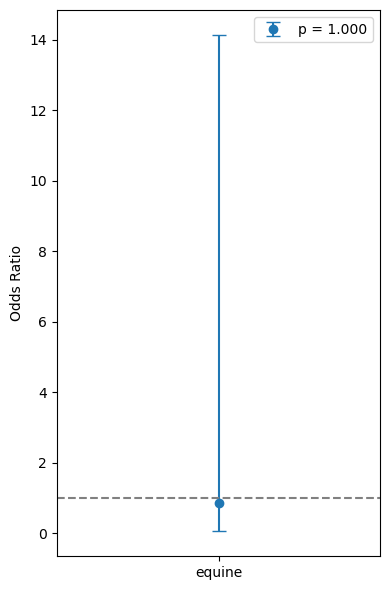

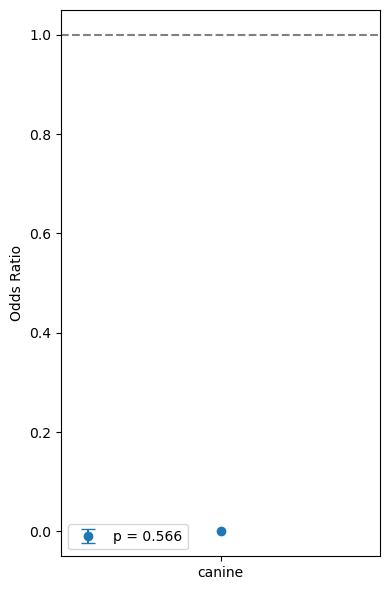

In [26]:
for clade, odds_ratio, p_value, (ci_low, ci_high) in zip(clades, odds_ratios, p_values, confidence):
    plt.figure(figsize=(4, 6))

    plt.errorbar(
        x=0,
        y=odds_ratio,
        yerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
        fmt='o',
        color='tab:blue',
        capsize=5,
        label=f'p = {p_value:.3f}'
    )

    plt.axhline(1, color='gray', linestyle='--')  # neutral OR
    plt.xticks([0], [clade])  # show label on x-axis
    plt.ylabel('Odds Ratio')
    plt.legend()
    plt.tight_layout()
    plt.show()

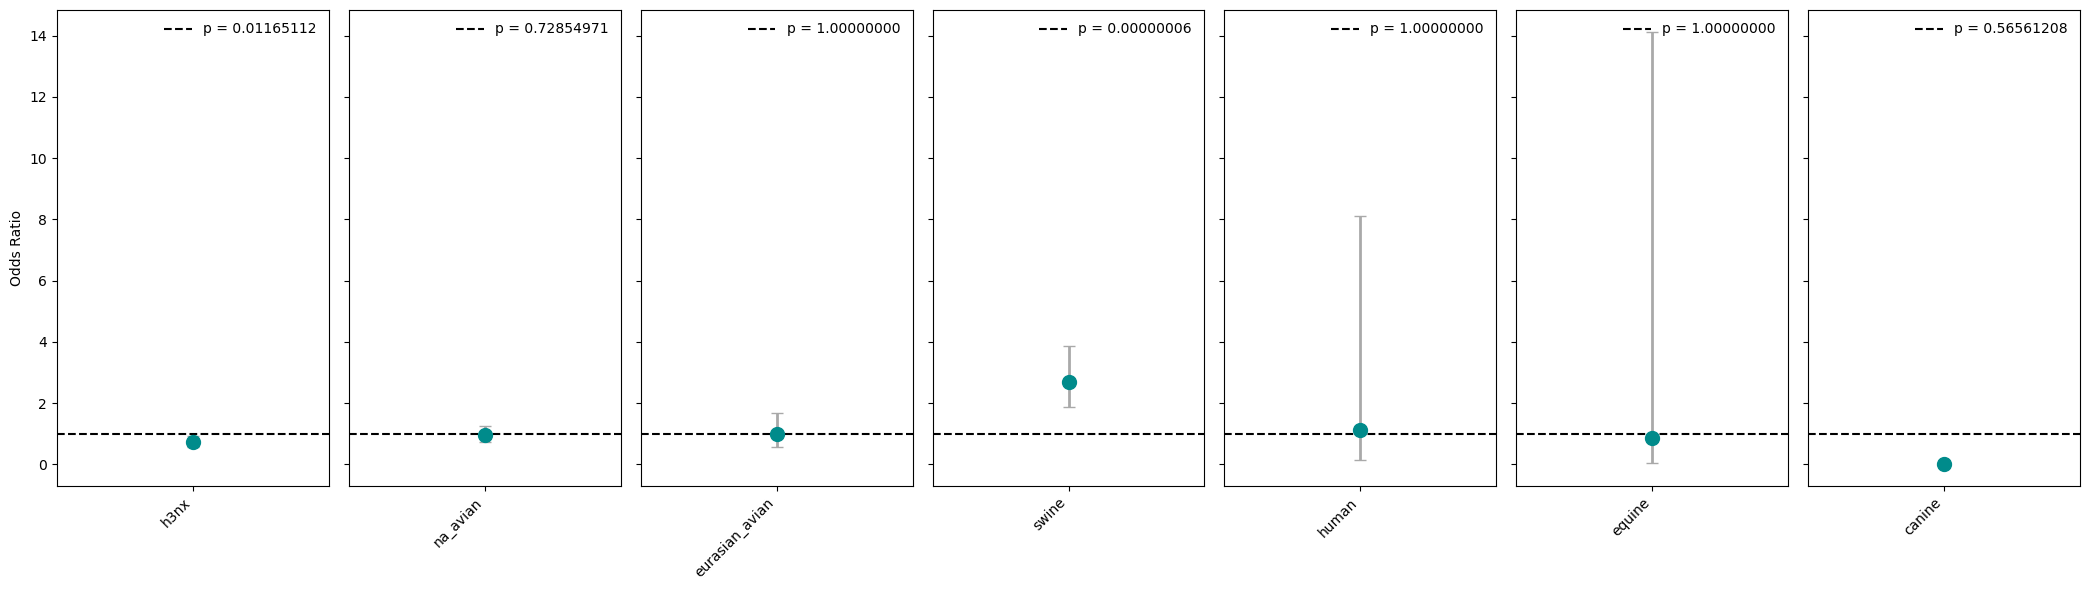

In [27]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)

    ax.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()


# 6 months

In [28]:
current_year = 2025
fit_time = 0.5

node_rea_counts = {clade: {} for clade in host_trees.keys()}
leaf_rea_counts = {clade: {} for clade in host_trees.keys()}

node_counts = {clade: {} for clade in host_trees.keys()}
leaf_counts = {clade: {} for clade in host_trees.keys()}

rea_fits = {clade: {} for clade in host_trees.keys()}
clonal_fits = {clade: {} for clade in host_trees.keys()}
rea_unfits = {clade: {} for clade in host_trees.keys()}
clonal_unfits = {clade: {} for clade in host_trees.keys()}


for clade in clades:
    
    mytree = host_trees[clade] 

    node_count = node_rea_count = leaf_count = leaf_rea_count= 0

    rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])


    for k in mytree.Objects:

        # for the fisher's exact test

        if k.is_leaf():

            leaf_count += 1

            if k.traits.get('is_reassorted'):

                leaf_rea_count += 1

        elif k.is_node():

            node_count += 1

            if k.traits.get('is_reassorted'):

                node_rea_count += 1

            # for the lineage fitness analysis

            # excluding nodes that are less than 2 years old 

            if (k.height / host_stats[clade]['clock_rate']) >= (current_year - host_stats[clade]['root_yr']) - fit_time:
                continue

            # which is correct? 

            # 1. find the leaf with the highest root to tip divergence (height) 
            # then subtract the current node's height from that leafs height

            # leaf_height = max(leaf_heights[leaf][0] for leaf in k.leaves)

            # 2. find the tip with the latest date and subtract the current node's height from that leafs height

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

            date = (leaf_height - k.height) / host_stats[clade]['clock_rate']

            # date = int(max_date[:4]) - ((k.height / clock_rate) + root_yr)

            if date > fit_time:

                if k.traits.get('is_reassorted'):
                    rea_fit += 1

                else:
                    clonal_fit += 1     

            else:

                if k.traits.get('is_reassorted'):
                    rea_unfit += 1

                else:
                    clonal_unfit += 1
                    
        node_counts[clade] = node_count
        leaf_counts[clade] = leaf_count

        node_rea_counts[clade] = node_rea_count
        leaf_rea_counts[clade] = leaf_rea_count


        rea_fits[clade] = rea_fit
        clonal_fits[clade] = clonal_fit

        rea_unfits[clade] = rea_unfit
        clonal_unfits[clade] = clonal_unfit


In [29]:
print(rea_fits)
print(clonal_fits)

print(rea_unfits)
print(clonal_unfits)

{'h3nx': 221, 'na_avian': 174, 'eurasian_avian': 49, 'swine': 113, 'human': 4, 'equine': 1, 'canine': 1}
{'h3nx': 1057, 'na_avian': 481, 'eurasian_avian': 389, 'swine': 999, 'human': 177, 'equine': 172, 'canine': 214}
{'h3nx': 85, 'na_avian': 112, 'eurasian_avian': 13, 'swine': 31, 'human': 0, 'equine': 1, 'canine': 2}
{'h3nx': 361, 'na_avian': 367, 'eurasian_avian': 102, 'swine': 715, 'human': 53, 'equine': 49, 'canine': 207}


In [30]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []


for clade in clades:
    a = rea_fits[clade]
    b = rea_unfits[clade]
    c = clonal_fits[clade]
    d = clonal_unfits[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts for {clade} are 0")
        ci_low, ci_high = float('nan'), float('nan')
        
    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade}: p-value = {p_value:.6f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

h3nx: p-value = 0.428526, odds ratio = 0.89, 95% CI = (0.6729890089089532, 1.1716641819671785)
na_avian: p-value = 0.239483, odds ratio = 1.19, 95% CI = (0.9016722693631348, 1.558316659788025)
eurasian_avian: p-value = 1.000000, odds ratio = 0.99, 95% CI = (0.5163738159099714, 1.8916569667544294)
swine: p-value = 0.000001, odds ratio = 2.61, 95% CI = (1.7334333255588772, 3.9265168432867044)
one of your counts for human are 0
human: p-value = 0.576875, odds ratio = inf, 95% CI = (nan, nan)
equine: p-value = 0.398942, odds ratio = 0.28, 95% CI = (0.017498421750333202, 4.63806025532041)
canine: p-value = 0.618845, odds ratio = 0.48, 95% CI = (0.04352164064046803, 5.374621613095105)


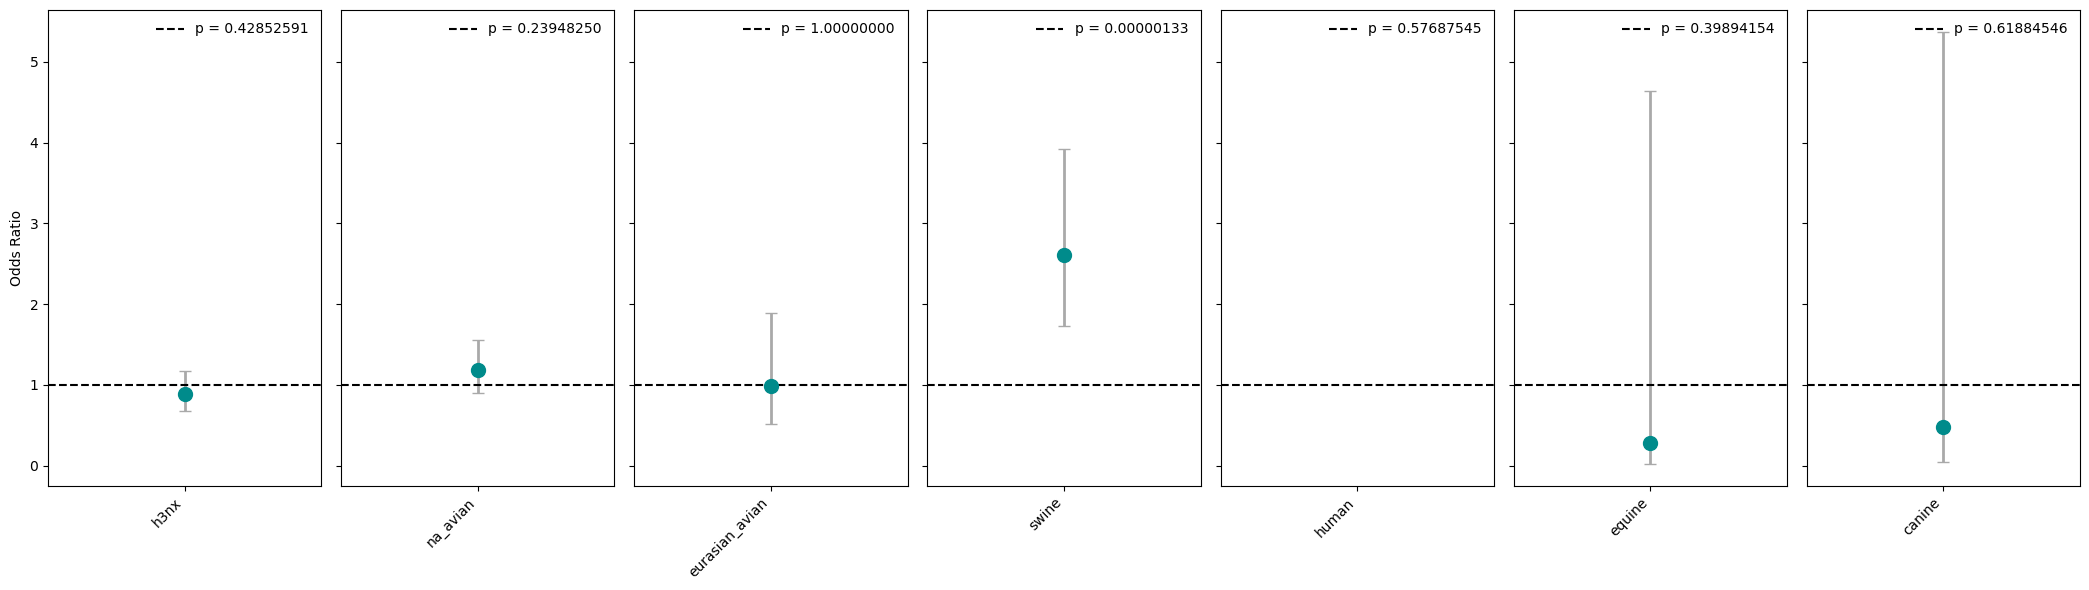

In [31]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)

    ax.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()


# ~2 months

In [32]:
current_year = 2025
fit_time = 0.1

node_rea_counts = {clade: {} for clade in host_trees.keys()}
leaf_rea_counts = {clade: {} for clade in host_trees.keys()}

node_counts = {clade: {} for clade in host_trees.keys()}
leaf_counts = {clade: {} for clade in host_trees.keys()}

rea_fits = {clade: {} for clade in host_trees.keys()}
clonal_fits = {clade: {} for clade in host_trees.keys()}
rea_unfits = {clade: {} for clade in host_trees.keys()}
clonal_unfits = {clade: {} for clade in host_trees.keys()}


for clade in clades:
    
    mytree = host_trees[clade] 

    node_count = node_rea_count = leaf_count = leaf_rea_count= 0

    rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])


    for k in mytree.Objects:

        # for the fisher's exact test

        if k.is_leaf():

            leaf_count += 1

            if k.traits.get('is_reassorted'):

                leaf_rea_count += 1

        elif k.is_node():

            node_count += 1

            if k.traits.get('is_reassorted'):

                node_rea_count += 1

            # excluding nodes that are less than 2 mo old 

            if (k.height / host_stats[clade]['clock_rate']) >= (current_year - host_stats[clade]['root_yr']) - fit_time:
                continue

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

            date = (leaf_height - k.height) / host_stats[clade]['clock_rate']

            if date > fit_time:

                if k.traits.get('is_reassorted'):
                    rea_fit += 1

                else:
                    clonal_fit += 1     

            else:

                if k.traits.get('is_reassorted'):
                    rea_unfit += 1

                else:
                    clonal_unfit += 1
                    
        node_counts[clade] = node_count
        leaf_counts[clade] = leaf_count

        node_rea_counts[clade] = node_rea_count
        leaf_rea_counts[clade] = leaf_rea_count


        rea_fits[clade] = rea_fit
        clonal_fits[clade] = clonal_fit

        rea_unfits[clade] = rea_unfit
        clonal_unfits[clade] = clonal_unfit


In [33]:
print(rea_fits)
print(clonal_fits)

print(rea_unfits)
print(clonal_unfits)

{'h3nx': 247, 'na_avian': 211, 'eurasian_avian': 49, 'swine': 123, 'human': 4, 'equine': 2, 'canine': 1}
{'h3nx': 1192, 'na_avian': 590, 'eurasian_avian': 392, 'swine': 1295, 'human': 217, 'equine': 189, 'canine': 273}
{'h3nx': 60, 'na_avian': 76, 'eurasian_avian': 13, 'swine': 23, 'human': 0, 'equine': 0, 'canine': 2}
{'h3nx': 244, 'na_avian': 259, 'eurasian_avian': 104, 'swine': 434, 'human': 13, 'equine': 32, 'canine': 148}


In [34]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []


for clade in clades:
    a = rea_fits[clade]
    b = rea_unfits[clade]
    c = clonal_fits[clade]
    d = clonal_unfits[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts for {clade} are 0")
        ci_low, ci_high = float('nan'), float('nan')
        
    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade}: p-value = {p_value:.6f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

h3nx: p-value = 0.282324, odds ratio = 0.84, 95% CI = (0.6156371882856534, 1.1534365298748648)
na_avian: p-value = 0.203850, odds ratio = 1.22, 95% CI = (0.9027294870168526, 1.6454155689831524)
eurasian_avian: p-value = 1.000000, odds ratio = 1.00, 95% CI = (0.5227915832316726, 1.912808147786983)
swine: p-value = 0.011786, odds ratio = 1.79, 95% CI = (1.1332928749187854, 2.8343424070941574)
one of your counts for human are 0
human: p-value = 1.000000, odds ratio = inf, 95% CI = (nan, nan)
one of your counts for equine are 0
equine: p-value = 1.000000, odds ratio = inf, 95% CI = (nan, nan)
canine: p-value = 0.286438, odds ratio = 0.27, 95% CI = (0.024374207741007962, 3.014446892967922)


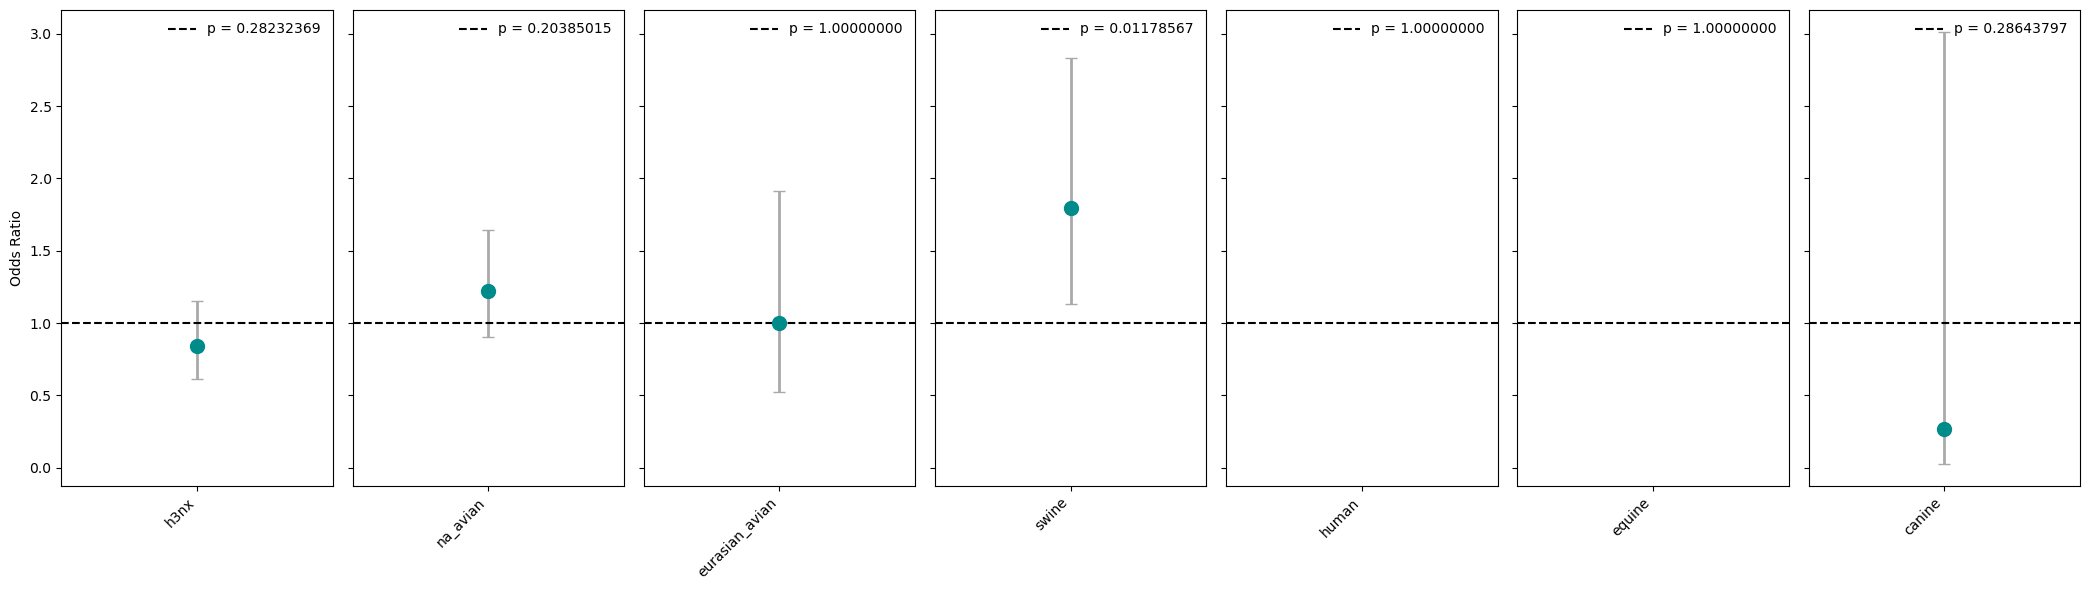

In [35]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)

    ax.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()
